charge library

In [74]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os
import sys
import matplotlib.pyplot as plt
sys.path.append(r"c:\pipeline  Analyse du Marché Immobilier darkom.ma\scripts")
from fonction_outlier import *
from fonction_categorie_prix import categorize_price
from fonction_categorie_surface import categorize_surface

In [75]:
#connexion:
load_dotenv()  # installer .env
user = os.getenv("DB_USER")
password = os.getenv("DB_PASSWORD")
host = os.getenv("DB_HOST")
port = os.getenv("DB_PORT")
db = os.getenv("DB_NAME")
DATABASE_URL = f"postgresql://{user}:{password}@{host}:{port}/{db}"
engine = create_engine(DATABASE_URL)
print("conexion ok")
df=pd.read_sql("select * from staging.darkom_annonces_raw",engine)

conexion ok


In [76]:
df.shape
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1508 entries, 0 to 1507
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   annonce_id          1508 non-null   str    
 1   date_publication    1432 non-null   str    
 2   titre               1508 non-null   str    
 3   ville               1508 non-null   str    
 4   quartier            1093 non-null   str    
 5   type_bien           1470 non-null   str    
 6   transaction         1470 non-null   str    
 7   prix                1508 non-null   float64
 8   surface             1508 non-null   float64
 9   nb_chambres         1379 non-null   float64
 10  nb_salles_bain      1404 non-null   float64
 11  etage               1276 non-null   float64
 12  annee_construction  1304 non-null   float64
dtypes: float64(6), str(7)
memory usage: 153.3 KB


,annonce_id,date_publication,titre,ville,quartier,type_bien,transaction,prix,surface,nb_chambres,nb_salles_bain,etage,annee_construction
0,ANO000343,2023-05-05,Terrain moderne Meknès,Meknès,Hamria,Terrain,Vente,811401.04,314.40,0.0,NaN,0.0,2014.0
1,ANO001296,2023-08-20,Terrain moderne Kenitra,Kenitra,Centre,Terrain,Location,3843.55,36.46,0.0,0.0,NaN,2008.0
2,ANO001212,2023-06-20,Appartement moderne Oujda,Oujda,Hay Qods,Appartement,Location,9190.70,95.54,2.0,2.0,NaN,2012.0
3,ANO001000,2024-01-21,Appartement à vente - Tanger,Tanger,NaN,Appartement,Vente,30000.00,93.35,1.0,1.0,3.0,2008.0
4,ANO001123,2024-03-19,Beau Villa Rabat,Rabat,Souissi,Villa,Location,20844.72,264.22,3.0,1.0,0.0,2006.0


In [77]:
df['date_publication']=pd.to_datetime(df['date_publication'],errors='coerce')
df['nb_salles_bain']=pd.to_numeric(df['nb_salles_bain'],errors='coerce')
df['nb_chambres']=pd.to_numeric(df['nb_chambres'],errors='coerce')
df['etage']=pd.to_numeric(df['etage'],errors='coerce')

In [78]:
#supprimer doubllonts:
df=df.drop_duplicates()

In [79]:
df = df.fillna({'date_publication':df['date_publication'].ffill(),
          'annee_construction':df['annee_construction'].bfill()     
})     
df = df.fillna({
    'quartier':df['quartier'].mode()[0],
    'type_bien':df['type_bien'].mode()[0],
    'transaction':df['transaction'].mode()[0]
    })
df=df.fillna({
    'nb_chambres':df['nb_chambres'].median(),
    'nb_salles_bain':df['nb_salles_bain'].median(),
    'etage':df['etage'].median()
})

In [80]:
df.info()

<class 'pandas.DataFrame'>
Index: 1500 entries, 0 to 1507
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   annonce_id          1500 non-null   str           
 1   date_publication    1500 non-null   datetime64[us]
 2   titre               1500 non-null   str           
 3   ville               1500 non-null   str           
 4   quartier            1500 non-null   str           
 5   type_bien           1500 non-null   str           
 6   transaction         1500 non-null   str           
 7   prix                1500 non-null   float64       
 8   surface             1500 non-null   float64       
 9   nb_chambres         1500 non-null   float64       
 10  nb_salles_bain      1500 non-null   float64       
 11  etage               1500 non-null   float64       
 12  annee_construction  1500 non-null   float64       
dtypes: datetime64[us](1), float64(6), str(6)
memory usage: 164.1 KB


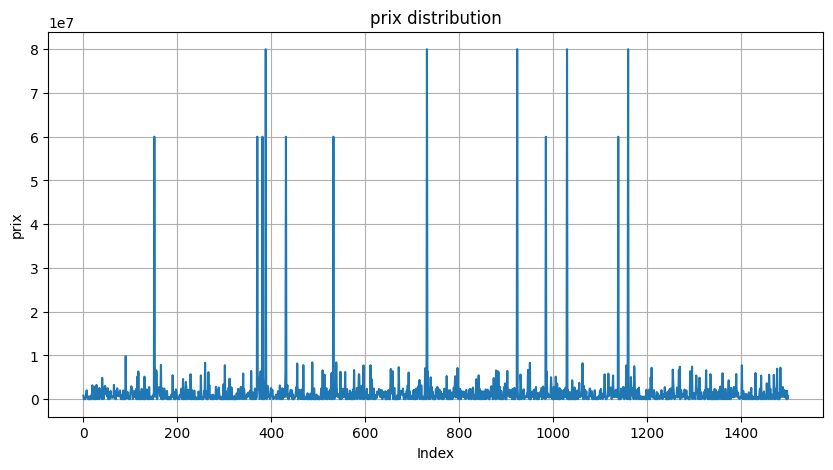

In [81]:
#graph prix 
plt.figure(figsize=(10,5))
plt.plot(df["prix"].values)
plt.title("prix distribution")
plt.xlabel("Index")
plt.ylabel("prix")
plt.grid()
plt.show()

In [82]:
# applique la fonction
df = detect_outliers_grouped(
    df,
    "prix",
    ["nb_chambres", "surface"]
)
# supprimer outliers:
df = df[df["outlier"] == False]
# supprimer colonne
df = df.drop("outlier", axis=1)

In [83]:
df

,annonce_id,date_publication,titre,ville,quartier,type_bien,transaction,prix,surface,nb_chambres,nb_salles_bain,etage,annee_construction
0,ANO000343,2023-05-05,Terrain moderne Meknès,Meknès,Hamria,Terrain,Vente,811401.04,314.40,0.0,1.0,0.0,2014.0
1,ANO001296,2023-08-20,Terrain moderne Kenitra,Kenitra,Centre,Terrain,Location,3843.55,36.46,0.0,0.0,1.0,2008.0
2,ANO001212,2023-06-20,Appartement moderne Oujda,Oujda,Hay Qods,Appartement,Location,9190.70,95.54,2.0,2.0,1.0,2012.0
3,ANO001000,2024-01-21,Appartement à vente - Tanger,Tanger,Centre,Appartement,Vente,30000.00,93.35,1.0,1.0,3.0,2008.0
4,ANO001123,2024-03-19,Beau Villa Rabat,Rabat,Souissi,Villa,Location,20844.72,264.22,3.0,1.0,0.0,2006.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1503,ANO000592,2024-10-22,Appartement moderne Agadir,Agadir,Hay Mohammadi,Appartement,Vente,573352.89,66.44,3.0,1.0,1.0,1999.0
1504,ANO001157,2024-01-05,Appartement à location - Marrakech,Marrakech,Hivernage,Appartement,Location,1981.82,79.53,4.0,3.0,3.0,2009.0
1505,ANO000333,2023-08-30,Beau Bureau Agadir,Agadir,Hay Mohammadi,Bureau,Vente,1919074.61,145.63,0.0,0.0,0.0,2005.0
1506,ANO001089,2024-06-05,Villa 405m² Ain Diab,Casablanca,Ain Diab,Villa,Location,10130.83,405.30,5.0,3.0,1.0,1986.0


In [84]:
df["ville"]=df["ville"].str.strip().str.lower().replace("casa","casablanca")
df["type_bien"]=df["type_bien"].str.strip().str.lower()
unique=df["ville"].unique()
print(unique)

<StringArray>
[    'meknès',    'kenitra',      'oujda',     'tanger',      'rabat',
     'agadir',        'fès', 'casablanca',    'tétouan',  'marrakech']
Length: 10, dtype: str


Feature Engineering


In [85]:
df["prix_m2"] = df["prix"] / df["surface"]
df["age_bien"] = 2026 - df["annee_construction"]
#applique fonction categorie prix:
df["categorie_prix"] = df["prix"].apply(categorize_price)
#applique fonction categorie surface:
df['categorie_surface'] = df['surface'].apply(categorize_surface)
df["annee"] = df["date_publication"].dt.year
df["mois"] = df["date_publication"].dt.month
df["trimestre"] = df["date_publication"].dt.quarter

In [86]:
df

,annonce_id,date_publication,titre,ville,quartier,type_bien,transaction,prix,surface,nb_chambres,nb_salles_bain,etage,annee_construction,prix_m2,age_bien,categorie_prix,categorie_surface,annee,mois,trimestre
0,ANO000343,2023-05-05,Terrain moderne Meknès,meknès,Hamria,terrain,Vente,811401.04,314.40,0.0,1.0,0.0,2014.0,2580.792112,12.0,Moyen,Grand,2023,5,2
1,ANO001296,2023-08-20,Terrain moderne Kenitra,kenitra,Centre,terrain,Location,3843.55,36.46,0.0,0.0,1.0,2008.0,105.418267,18.0,Économique,Petit,2023,8,3
2,ANO001212,2023-06-20,Appartement moderne Oujda,oujda,Hay Qods,appartement,Location,9190.70,95.54,2.0,2.0,1.0,2012.0,96.197404,14.0,Économique,Moyen,2023,6,2
3,ANO001000,2024-01-21,Appartement à vente - Tanger,tanger,Centre,appartement,Vente,30000.00,93.35,1.0,1.0,3.0,2008.0,321.371184,18.0,Économique,Moyen,2024,1,1
4,ANO001123,2024-03-19,Beau Villa Rabat,rabat,Souissi,villa,Location,20844.72,264.22,3.0,1.0,0.0,2006.0,78.891530,20.0,Économique,Grand,2024,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1503,ANO000592,2024-10-22,Appartement moderne Agadir,agadir,Hay Mohammadi,appartement,Vente,573352.89,66.44,3.0,1.0,1.0,1999.0,8629.634106,27.0,Moyen,Petit,2024,10,4
1504,ANO001157,2024-01-05,Appartement à location - Marrakech,marrakech,Hivernage,appartement,Location,1981.82,79.53,4.0,3.0,3.0,2009.0,24.919150,17.0,Économique,Petit,2024,1,1
1505,ANO000333,2023-08-30,Beau Bureau Agadir,agadir,Hay Mohammadi,bureau,Vente,1919074.61,145.63,0.0,0.0,0.0,2005.0,13177.742292,21.0,Haut standing,Moyen,2023,8,3
1506,ANO001089,2024-06-05,Villa 405m² Ain Diab,casablanca,Ain Diab,villa,Location,10130.83,405.30,5.0,3.0,1.0,1986.0,24.995880,40.0,Économique,Grand,2024,6,2


In [87]:
df.to_sql(
    "darkom_annonces_clean",
    engine,
    schema="clean",
    if_exists="replace",
    index=False
)

500